In [1]:
!pip install scikit-fuzzy scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [4]:
iris= load_iris()
df= pd.DataFrame(iris.data, columns= iris.feature_names)



In [7]:
df['species']= pd.Categorical.from_codes(iris.target, iris.target_names)

In [9]:
df_train, df_test= train_test_split(df, test_size=0.3, random_state=42)

In [10]:
features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

In [11]:
species = iris.target_names

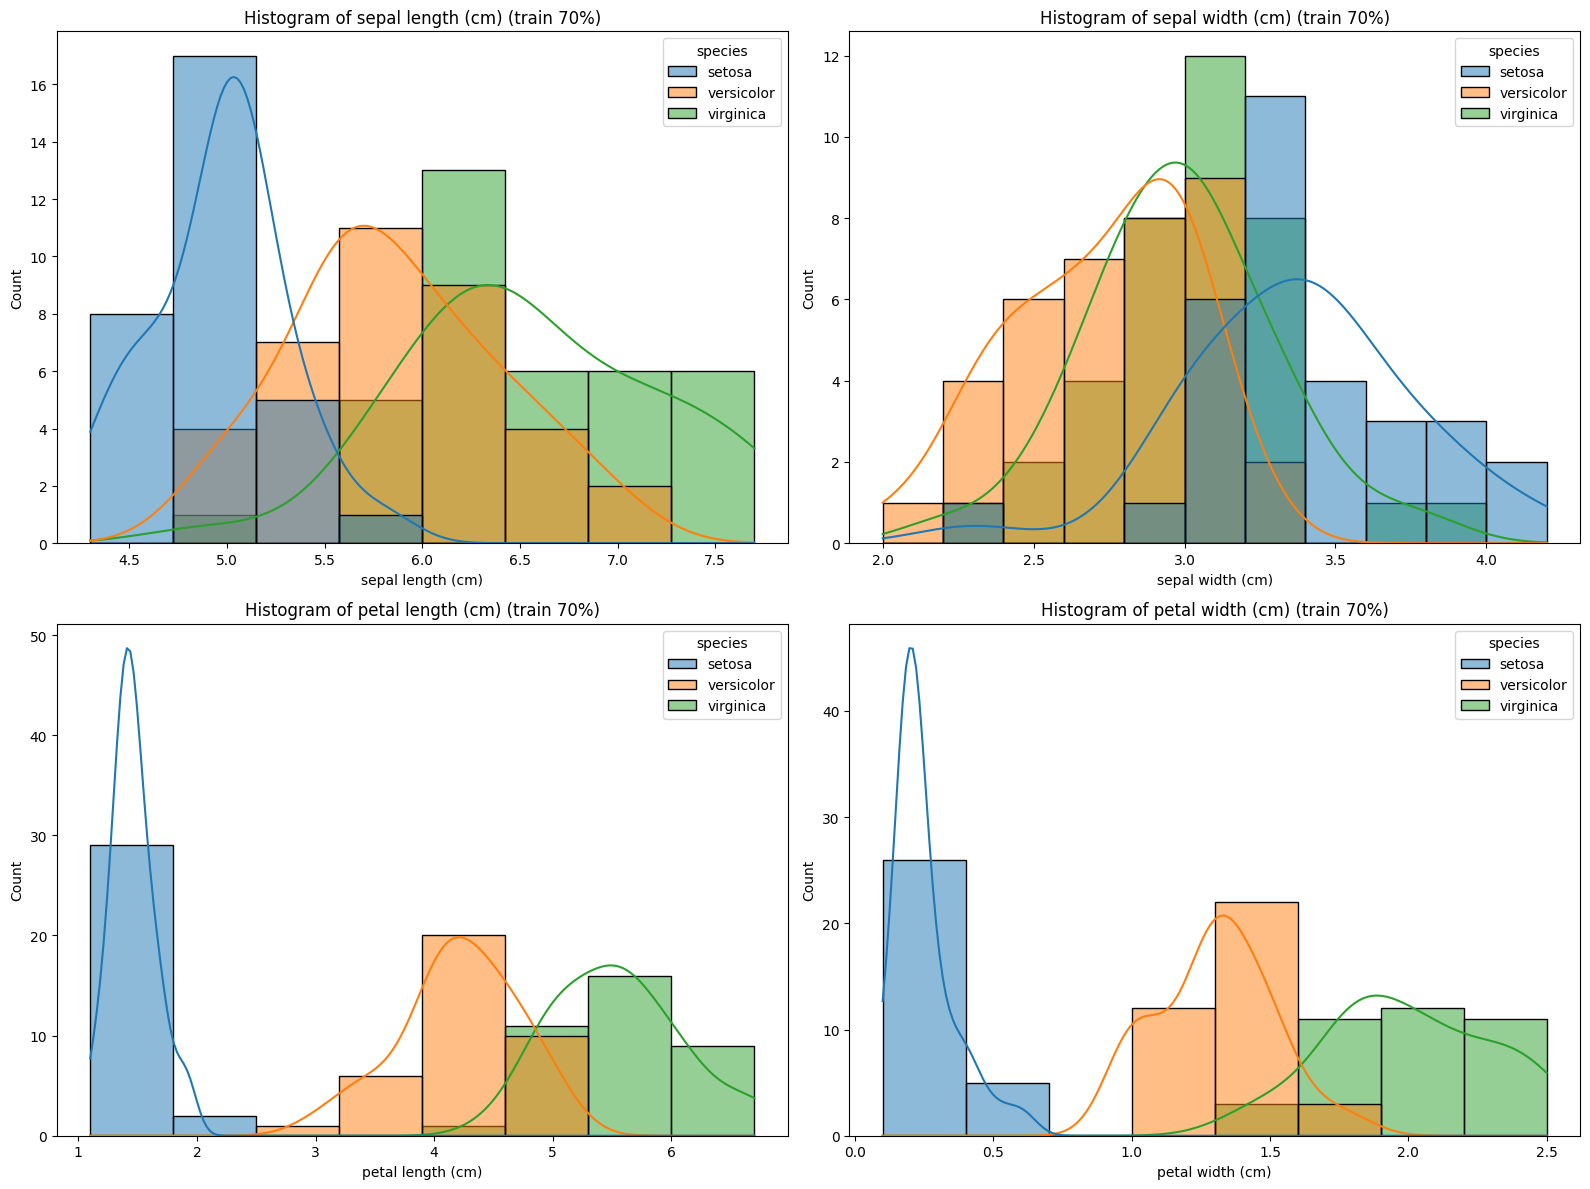

In [12]:
plt.figure(figsize=(16, 12))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(
        data=df_train,
        x=feature,
        hue="species",
        kde=True
    )
    plt.title(f"Histogram of {feature} (train 70%)")
    plt.xlabel(feature)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

/tmp/ipykernel_999/968793004.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


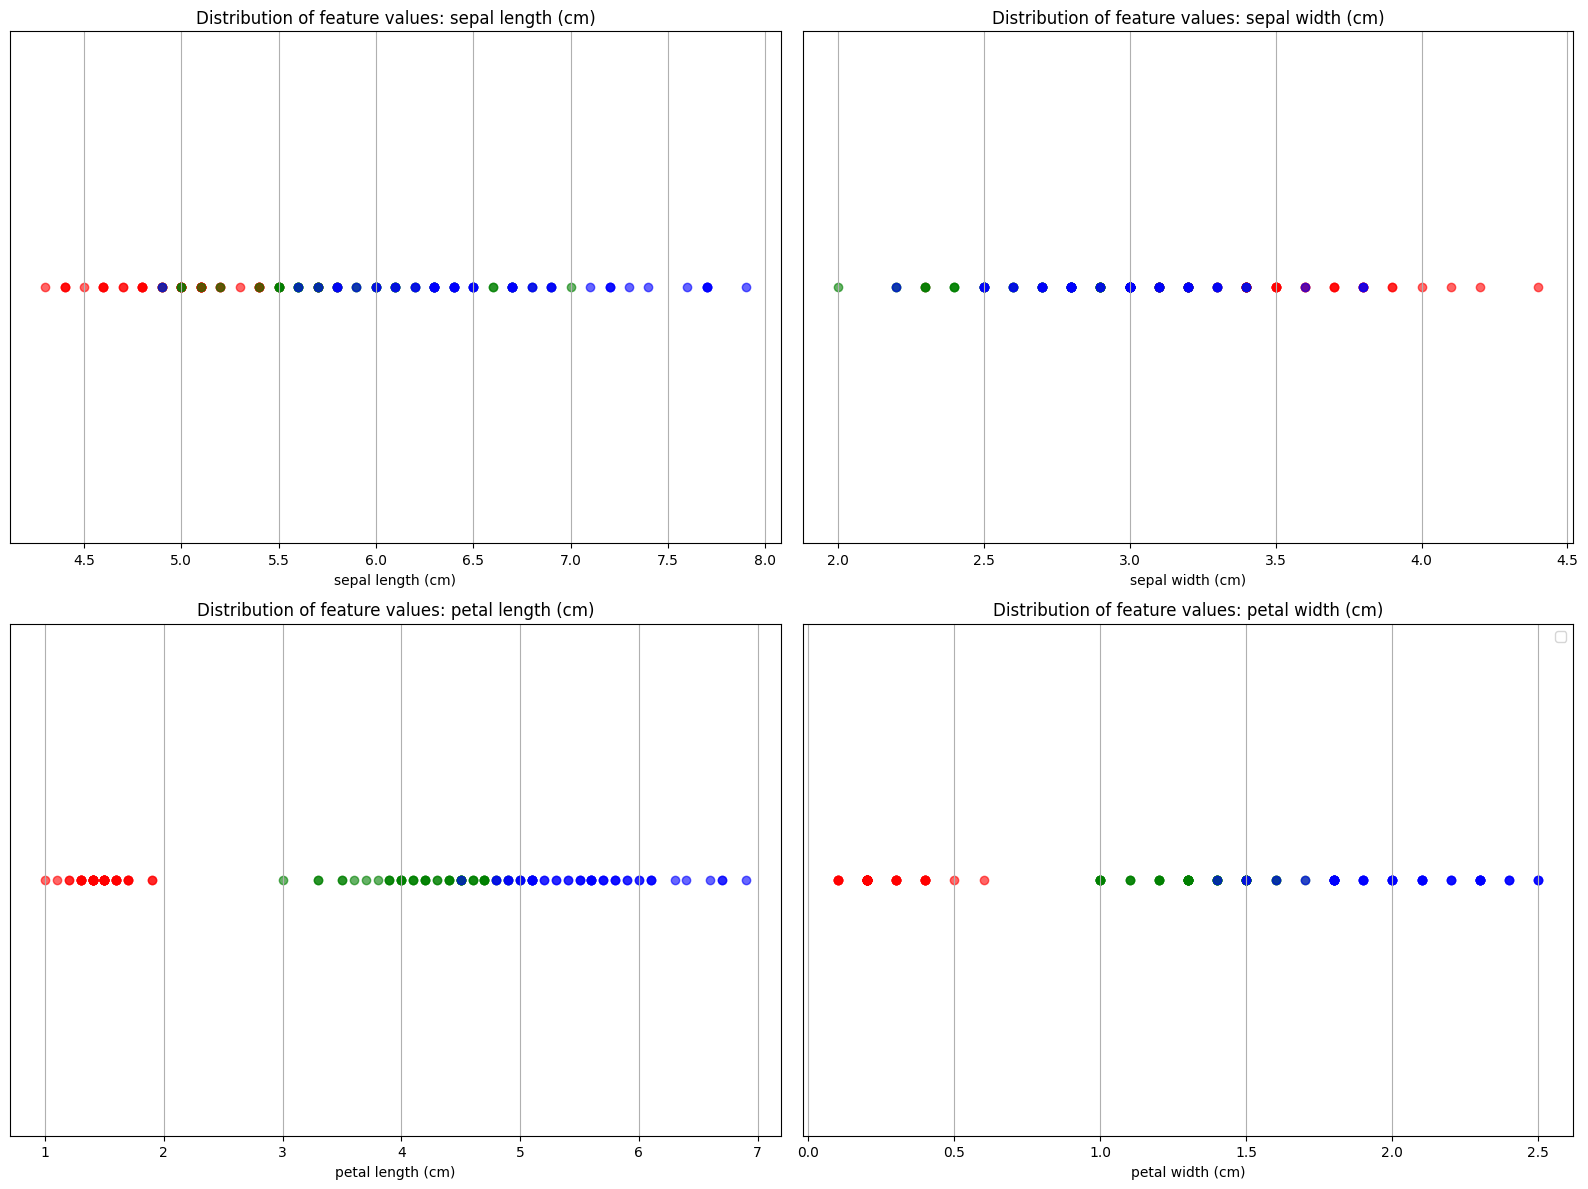

In [14]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris



iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)


species_colors = {
    'setosa': 'red',
    'versicolor': 'green',
    'virginica': 'blue'
}


features = iris.feature_names


plt.figure(figsize=(16, 12))


for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    for species_name, color in species_colors.items():
        subset = df[df['species'] == species_name]
        plt.scatter(subset[feature], [0]*len(subset), label=species_name if i==1 else "", color=color, alpha=0.6)
    plt.title(f'Distribution of feature values: {feature}')
    plt.xlabel(feature)
    plt.yticks([])
    plt.grid(True)


plt.legend()
plt.tight_layout()
plt.show()


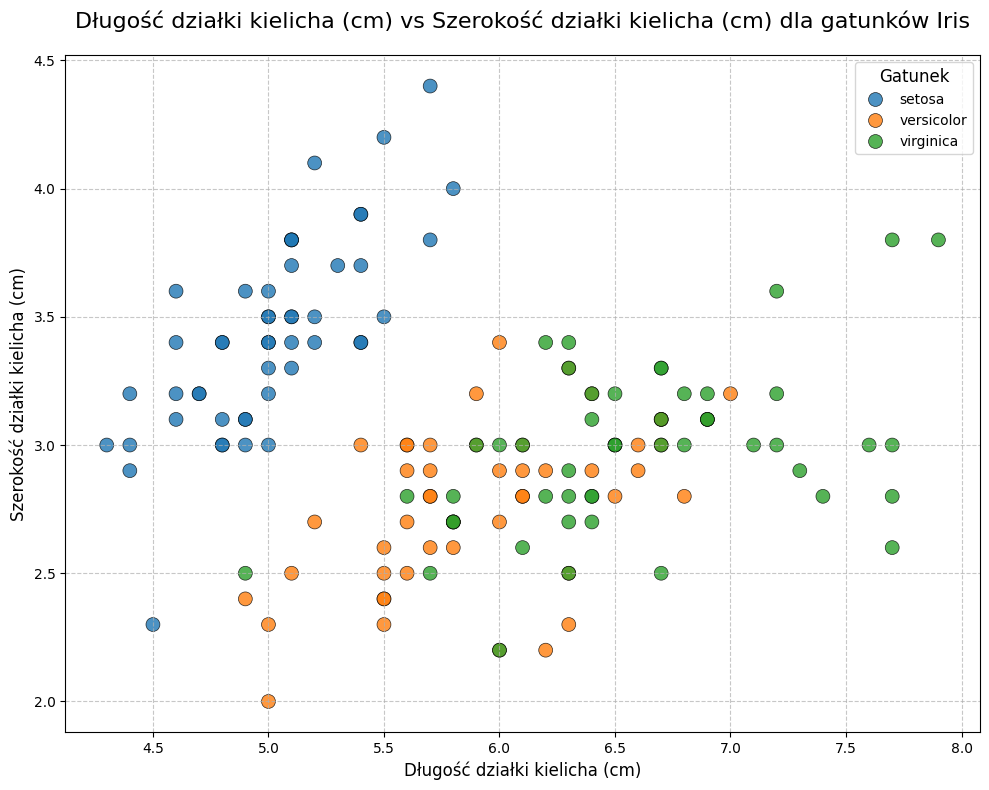

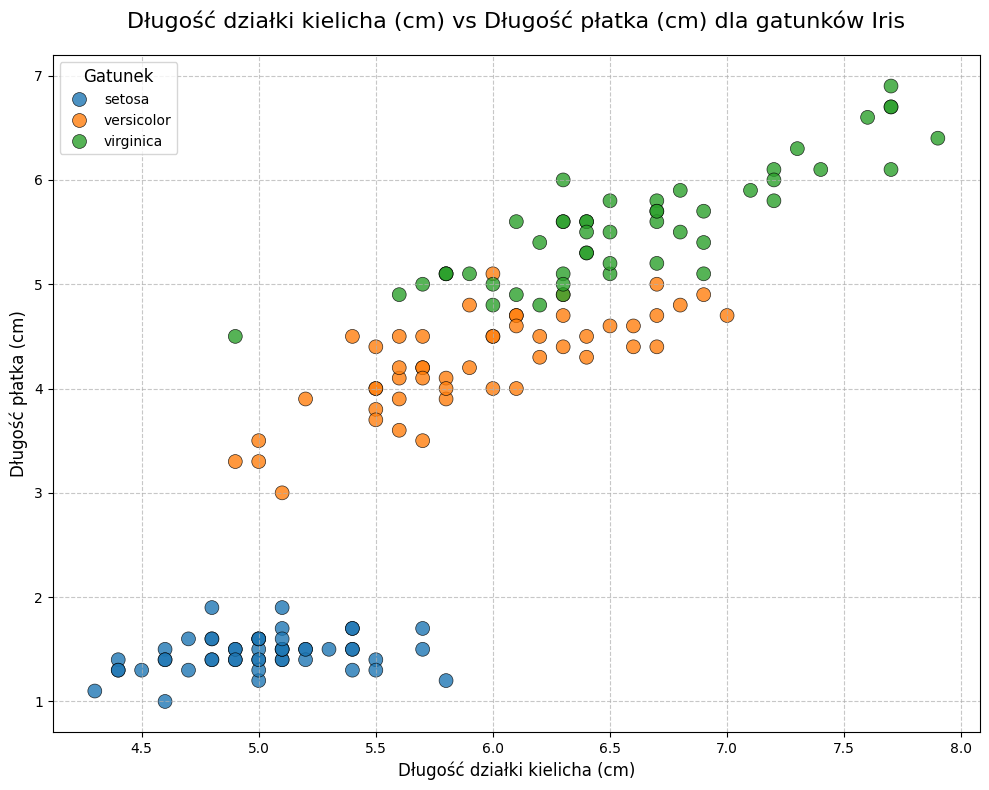

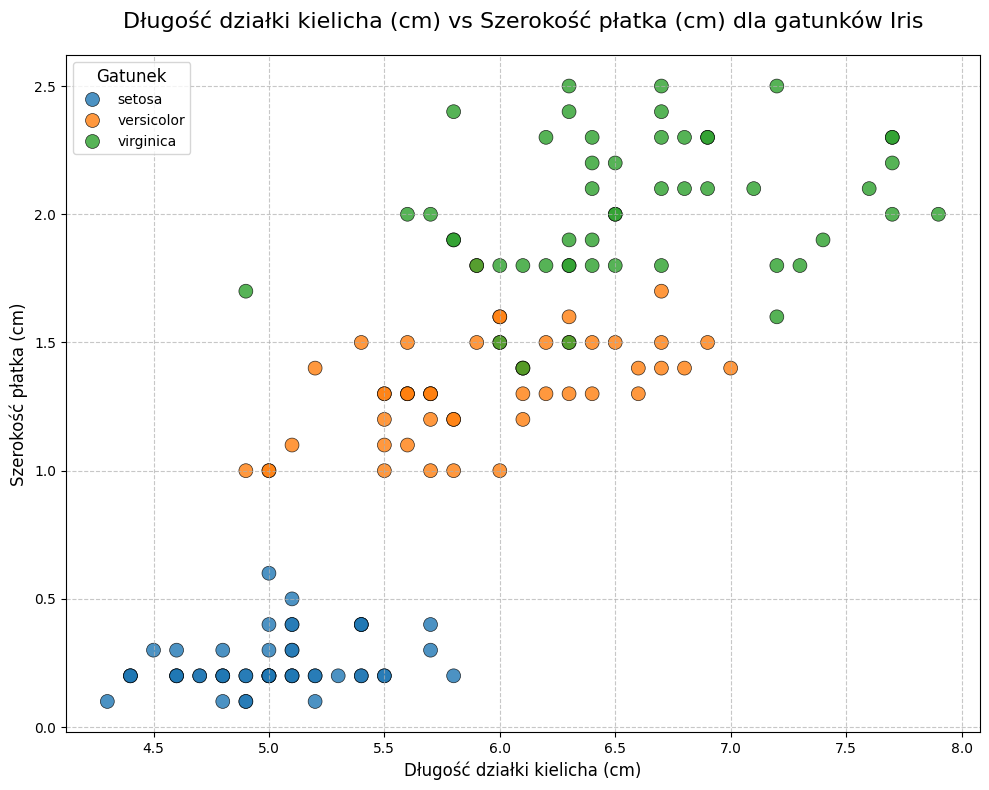

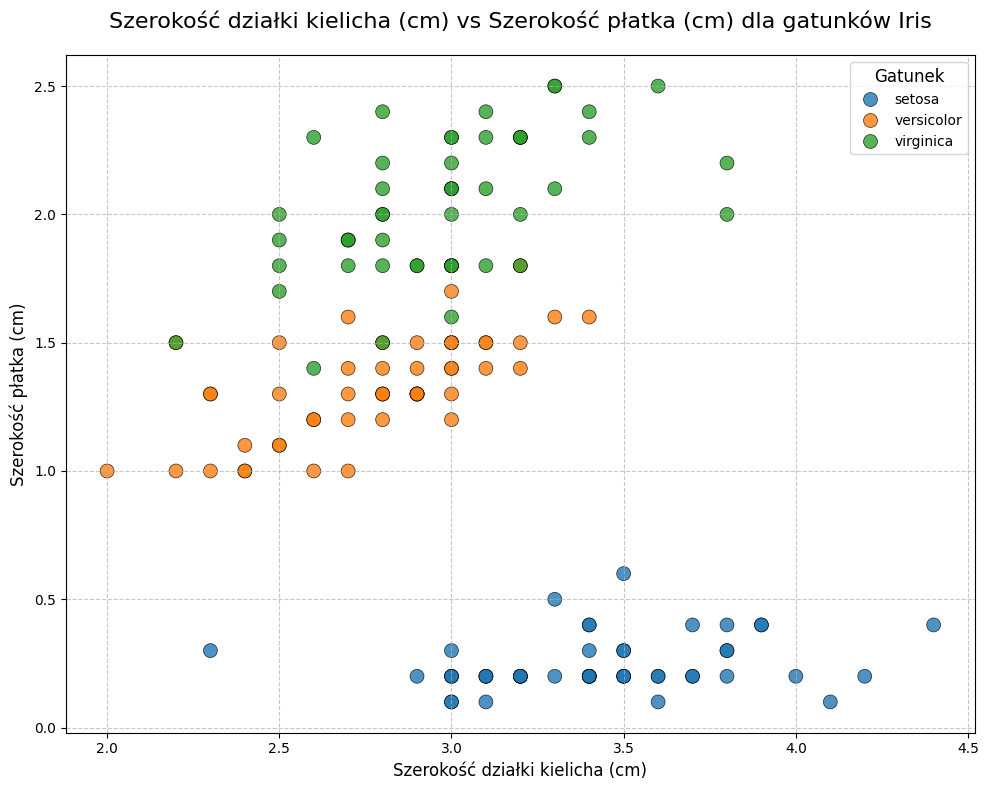

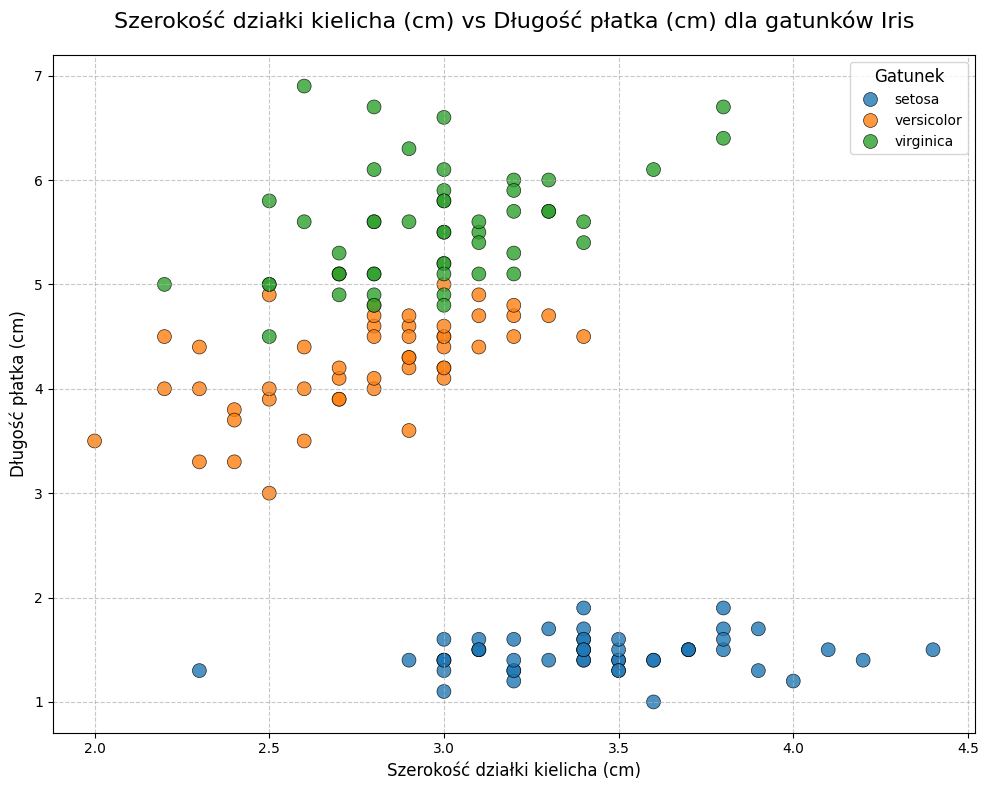

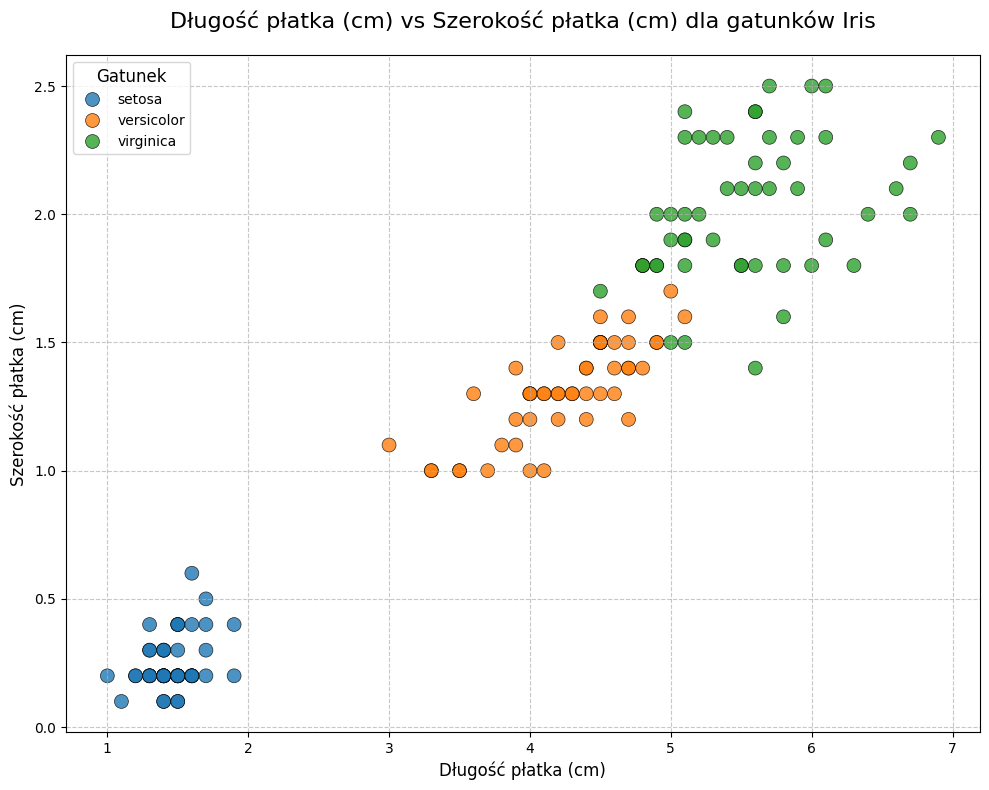

In [15]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
import math

df = sns.load_dataset("iris")


feature_pairs = [
    ('sepal_length', 'sepal_width'),
    ('sepal_length', 'petal_length'),
    ('sepal_length', 'petal_width'),
    ('sepal_width', 'petal_width'),
    ('sepal_width', 'petal_length'),
    ('petal_length', 'petal_width')
]


feature_names_pl = {
    'sepal_length': 'Długość działki kielicha (cm)',
    'sepal_width': 'Szerokość działki kielicha (cm)',
    'petal_length': 'Długość płatka (cm)',
    'petal_width': 'Szerokość płatka (cm)'
}




for x_feature, y_feature in feature_pairs:
    plt.figure(figsize=(10, 8))


    scatter = sns.scatterplot(
        data=df,
        x=x_feature,
        y=y_feature,
        hue='species',
        s=100,
        alpha=0.8,
        edgecolor='k',
        linewidth=0.5
    )


    x_name_pl = feature_names_pl[x_feature]
    y_name_pl = feature_names_pl[y_feature]


    plt.title(f'{x_name_pl} vs {y_name_pl} dla gatunków Iris', fontsize=16, pad=20)
    plt.xlabel(x_name_pl, fontsize=12)
    plt.ylabel(y_name_pl, fontsize=12)




    plt.legend(title='Gatunek', fontsize=10, title_fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()


    plt.show()

In [20]:
results=[]
for feature in features:
  for specie in species:
    data= df_test[df_test['species']== specie][feature]
    results.append({
        'Feature': feature,
        'Specie': specie,
        'Minimum': data.min(),
        'Maximum': data.max(),
        'Mean': data.mean()}
    )

In [21]:
summary_df= pd.DataFrame(results)
summary_df

,Feature,Specie,Minimum,Maximum,Mean
0,sepal length (cm),setosa,4.4,5.7,5.073684
1,sepal length (cm),versicolor,5.6,6.8,6.146154
2,sepal length (cm),virginica,5.8,7.9,6.669231
3,sepal width (cm),setosa,3.0,4.4,3.510526
4,sepal width (cm),versicolor,2.2,3.4,2.900000
5,sepal width (cm),virginica,2.5,3.8,2.938462
6,petal length (cm),setosa,1.0,1.7,1.457895
7,petal length (cm),versicolor,3.6,4.8,4.400000
8,petal length (cm),virginica,4.9,6.9,5.569231
9,petal width (cm),setosa,0.1,0.4,0.242105


In [22]:
iris= load_iris()
x= iris.data[:,:]
y=iris.target

In [23]:
x_test= x
y_test= y

In [32]:
from skfuzzy import control as ctrl
import skfuzzy as fuzz

In [47]:
sepal_length= ctrl.Antecedent(np.linspace(4,8,1000), 'sepal_length')
sepal_width= ctrl.Antecedent(np.linspace(2,5,1000), 'sepal_width')
petal_length= ctrl.Antecedent(np.linspace(1,7,1000), 'petal_length')
petal_width= ctrl.Antecedent(np.linspace(0,3,1000), 'petal_width')

In [48]:
species= ctrl.Consequent(np.linspace(0,2, 1000), 'species')

In [49]:
sepal_length['setosa']= fuzz.trimf(sepal_length.universe, [4.15, 5.01, 5.95])
sepal_length['versicolor']= fuzz.trimf(sepal_length.universe, [4.7, 5.75, 7.2])
sepal_length['virginica']= fuzz.trimf(sepal_length.universe, [4.7, 6.41, 8.1])

In [50]:
sepal_width['setosa'] = fuzz.trimf(sepal_width.universe, [2.1, 3.40, 4.6])
sepal_width['versicolor'] = fuzz.trimf(sepal_width.universe, [1.8, 2.90, 3.6])
sepal_width['virginica'] = fuzz.trimf(sepal_width.universe, [2.0, 2.98, 4.0])

petal_length['setosa'] = fuzz.trimf(petal_length.universe, [0.9, 1.45, 2.0])
petal_length['versicolor'] = fuzz.trimf(petal_length.universe, [2.8, 4.47, 5.3])
petal_length['virginica'] = fuzz.trimf(petal_length.universe, [4.3, 5.50, 7.1])

petal_width['setosa'] = fuzz.trimf(petal_width.universe, [0.095, 0.20, 0.65])
petal_width['versicolor'] = fuzz.trimf(petal_width.universe, [0.9, 1.34, 1.9])
petal_width['virginica'] = fuzz.trimf(petal_width.universe, [1.3, 1.89, 2.6])

In [51]:
species['setosa']=fuzz.trimf(species.universe, [0,0, 0.5])
species['versicolor']=fuzz.trimf(species.universe, [0.5,1, 1.5])
species['virginica']=fuzz.trimf(species.universe, [1.5,2, 2])

In [52]:
# Definicja reguł
# SETOSA
rule1 = ctrl.Rule(sepal_length['setosa'] & sepal_width['setosa'], species['setosa'])
rule2 = ctrl.Rule(sepal_length['setosa'] & petal_length['setosa'], species['setosa'])
rule3 = ctrl.Rule(sepal_length['setosa'] & petal_width['setosa'], species['setosa'])
rule4 = ctrl.Rule(sepal_width['setosa'] & petal_length['setosa'], species['setosa'])
rule5 = ctrl.Rule(sepal_width['setosa'] & petal_width['setosa'], species['setosa'])
rule6 = ctrl.Rule(petal_length['setosa'] & petal_width['setosa'], species['setosa'])

# VERSICOLOR
rule7 = ctrl.Rule(sepal_length['versicolor'] & sepal_width['versicolor'], species['versicolor'])
rule8 = ctrl.Rule(sepal_length['versicolor'] & petal_length['versicolor'], species['versicolor'])
rule9 = ctrl.Rule(sepal_length['versicolor'] & petal_width['versicolor'], species['versicolor'])
rule10 = ctrl.Rule(sepal_width['versicolor'] & petal_length['versicolor'], species['versicolor'])
rule11 = ctrl.Rule(sepal_width['versicolor'] & petal_width['versicolor'], species['versicolor'])
rule12 = ctrl.Rule(petal_length['versicolor'] & petal_width['versicolor'], species['versicolor'])

# VIRGINICA
rule13 = ctrl.Rule(sepal_length['virginica'] & sepal_width['virginica'], species['virginica'])
rule14 = ctrl.Rule(sepal_length['virginica'] & petal_length['virginica'], species['virginica'])
rule15 = ctrl.Rule(sepal_length['virginica'] & petal_width['virginica'], species['virginica'])
rule16 = ctrl.Rule(sepal_width['virginica'] & petal_length['virginica'], species['virginica'])
rule17 = ctrl.Rule(sepal_width['virginica'] & petal_width['virginica'], species['virginica'])
rule18 = ctrl.Rule(petal_length['virginica'] & petal_width['virginica'], species['virginica'])

In [53]:
species_ctrl= ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6,
    rule7, rule8, rule9, rule10, rule11, rule12,
    rule13, rule14, rule15, rule16, rule17, rule18
])

In [54]:
y_pred = []
for sl, sw, pl, pw in x_test:
    species_sim = ctrl.ControlSystemSimulation(species_ctrl)
    species_sim.input['sepal_length'] = sl
    species_sim.input['sepal_width'] = sw
    species_sim.input['petal_length'] = pl
    species_sim.input['petal_width'] = pw

    species_sim.compute()
    fuzzy_result = species_sim.output['species']

    if fuzzy_result < 0.5:
        y_pred.append(0)
    elif fuzzy_result < 1.5:
        y_pred.append(1)
    else:
        y_pred.append(2)

In [56]:
from sklearn.metrics import accuracy_score, classification_report

In [57]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))


              precision    recall  f1-score   support

      setosa       1.00      0.40      0.57        50
  versicolor       0.41      1.00      0.58        50
   virginica       1.00      0.18      0.31        50

    accuracy                           0.53       150
   macro avg       0.80      0.53      0.49       150
weighted avg       0.80      0.53      0.49       150

